#  Pearson’s Correlation Coefficient for Feature Selection

**Pearson’s Product-Moment Correlation Coefficient $r$** is a **supervised, bivariate, filter-based** feature selection technique used to evaluate the linear relationship between continuous numeric variables. Unlike Variance Threshold , Pearson's correlation actively compares variables to identify patterns of co-movement.



In a machine learning feature selection pipeline, Pearson's correlation is deployed for two distinct purposes:
1.  **Target Relevance Analysis:** Measuring the strength of the linear relationship between an input feature ($X$) and a continuous target variable ($y$).

2.  **Multicollinearity Mitigation:** Identifying redundant, highly correlated pairs of input features ($X_i, X_j$) to prevent model instability.

## 1. Mathematical Architecture

The coefficient ($r$) is mathematically defined as the covariance of two variables divided by the product of their standard deviations:

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

Where:
*   $\mathbf{x_i, y_i}$ = Individual sample values for the two variables being compared.
*   $\mathbf{\bar{x}, \bar{y}}$ = The arithmetic means of the respective variables.
*   $\mathbf{n}$ = Total number of samples in the dataset.

### The Value Range and Mathematical Bounds
The value of $r$ is bounded strictly between **$-1$ and $+1$**:

*   $\mathbf{r = +1}$: Perfect positive linear relationship. As $X$ increases, $y$ increases in a perfectly constant linear ratio.
*   $\mathbf{r = 0}$: No **linear** relationship. The variables move independently of one another along a linear axis.
*   $\mathbf{r = -1}$: Perfect negative linear relationship. As $X$ increases, $y$ decreases in a perfectly constant linear ratio.

---

## 2. Decision Rules and Selection Thresholds $\rho_{\text{target}}$

When using Pearson's correlation to filter variables, you must choose your threshold ($\rho$) based on your objective:

### A. Rule for Target Relevance (Keeping Features)

You evaluate the absolute correlation between each feature and the continuous target: $\vert{}r_{X, y}\vert{}$.
*   **Keep Feature** if: $\vert{}r_{X, y}\vert{} \ge \rho_{\text{target}}$
*   **Drop Feature** if: $\vert{}r_{X, y}\vert{} < \rho_{\text{target}}$
*   *Standard Industry Practice:* Features with $\vert{}r\vert{} < 0.1$ are typically dropped as uninformative noise. Features with $\vert{}r\vert{} \ge 0.5$ are considered strong linear predictors.

### B. Rule for Multicollinearity (Dropping Redundant Features)

You compute an $m \times m$ correlation matrix of all input features against each other. If two features ($X_1$ and $X_2$) exhibit a correlation exceeding your threshold, they are redundant.
*   **Drop One Feature** if: $\vert{}r_{X_1, X_2}\vert{} > \rho_{\text{collinear}}$
*   *Standard Industry Practice:* $\rho_{\text{collinear}}$ is traditionally set between **$0.70$ and $0.90$**. If two columns exceed this, keep the one with the higher correlation to the target ($y$) and drop the other.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100


# 1. Load data & Inspect

In [3]:
df = pd.read_csv("../DataSets/WineQT.csv").drop(columns=["Id"])
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
816,6.1,0.580,0.23,2.5,0.044,16.0,70.0,0.99352,3.46,0.65,12.5,6
1045,7.3,0.480,0.32,2.1,0.062,31.0,54.0,0.99728,3.30,0.65,10.0,7
1119,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
364,10.5,0.510,0.64,2.4,0.107,6.0,15.0,0.99730,3.09,0.66,11.8,7
964,7.3,0.430,0.24,2.5,0.078,27.0,67.0,0.99648,3.60,0.59,11.1,6


`quality` is an integer score (3-8) given by tasters — treated here as a
continuous target for correlation purposes, which is standard practice for
this dataset even though it's technically ordinal.

In [4]:
# Data Info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [5]:
print(f"Total Number of Missing Values: {df.isnull().sum().sum()}")
print(df["quality"].value_counts().sort_index())

Total Number of Missing Values: 0
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


**Observation:** No missing values, 11 numeric physicochemical features,
target is skewed toward the middle scores (5 and 6) — worth remembering
later since Pearson correlation with a lopsided target can be noisier at
the extremes.

# 2. Pearson's Coefficient 

Pearson's r for two variables X and Y:

```
r = Σ((X - X̄)(Y - Ȳ)) / sqrt(Σ(X - X̄)² · Σ(Y - Ȳ)²)
```

i.e. covariance of X and Y, normalized by the product of their standard
deviations, so the result always lands in [-1, 1] regardless of the
original units. Do this by hand for `fixed acidity` vs `density` before
trusting any library call.

In [6]:
def pearson_correlation(df, feature1, feature2):
    """
    Calculate the Pearson correlation coefficient between two features in a DataFrame."""
    
    r, p = pearsonr(df[feature1], df[feature2])
    print(f"Correlation between {feature1} and {feature2}: {r:.4f}")
    if r < 0:
        print(f"Thus, '{feature1}' and '{feature2}' negatively correlated. (p_value = {p:.3e})")
    elif r > 0:
        print(f"Thus, '{feature1}' and '{feature2}' positively correlated.(p_value = {p:.3e})")
    else:
        print(f"Thus, '{feature1}' and '{feature2}' are not correlated.(p_value = {p:.3e})")

pearson_correlation(df, 'fixed acidity', 'density')

Correlation between fixed acidity and density: 0.6815
Thus, 'fixed acidity' and 'density' positively correlated.(p_value = 6.649e-157)


# 3. Correlation Matrix

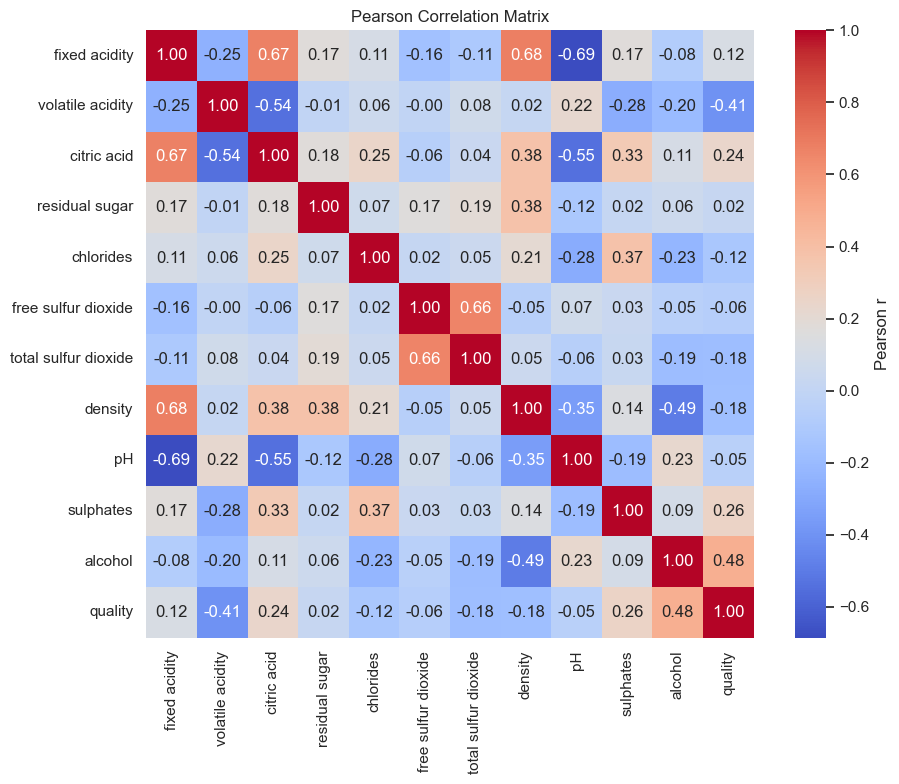

In [7]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix , annot=True,fmt =".2f", cmap='coolwarm', square=True, cbar_kws={"label": "Pearson r"})
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
#plt.savefig('correlation_matrix.png') To save 
plt.show()

### Compare Correlation of different features with target

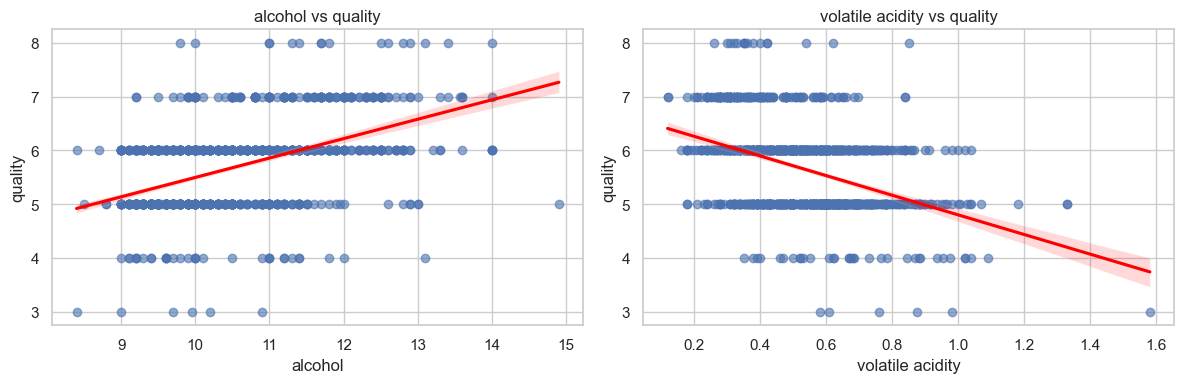

In [8]:
def corr_plot(df, features):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, feat in zip(axes, features):
        sns.regplot(
            data=df,
            x=feat,
            y="quality",
            ax=ax,
            scatter_kws={"alpha": 0.6},
            line_kws={"color": "red"}
        )
        ax.set_title(f"{feat} vs quality")
        ax.set_xlabel(feat)
        ax.set_ylabel("quality")
        
    plt.tight_layout()
    plt.show()

features = ["alcohol", "volatile acidity"] # Two features at a time with target
corr_plot(df, features)


# 4. Relevance of Feature vs target correlation

alcohol                 0.484866
volatile acidity       -0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide   -0.183339
density                -0.175208
chlorides              -0.124085
fixed acidity           0.121970
free sulfur dioxide    -0.063260
pH                     -0.052453
residual sugar          0.022002
Name: quality, dtype: float64


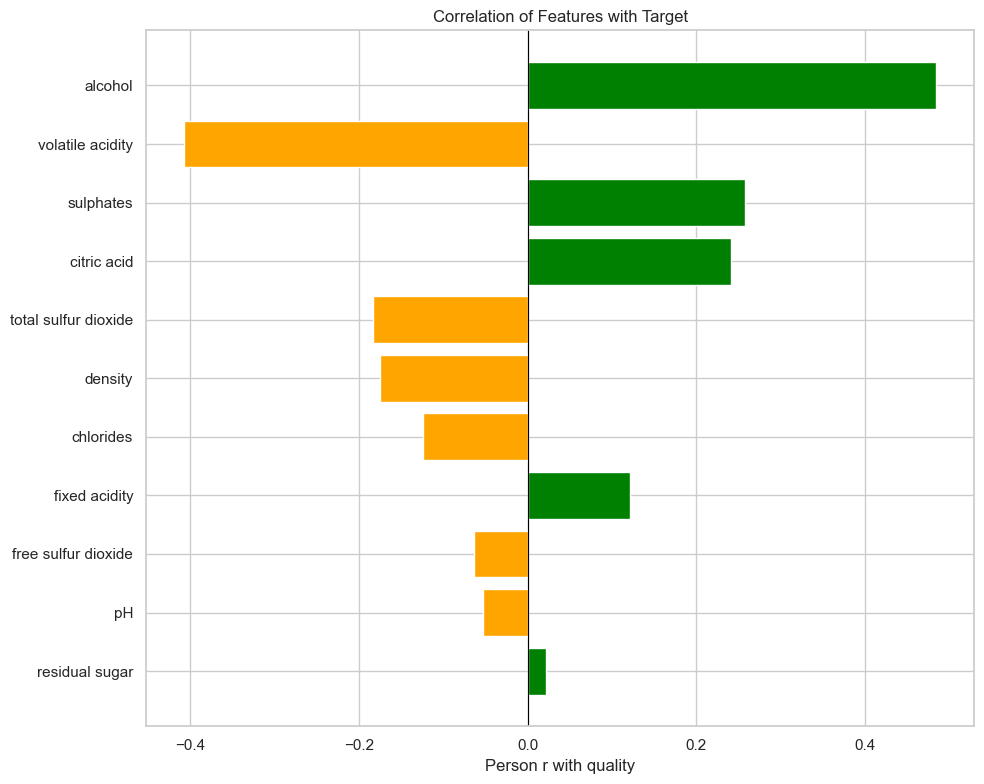

In [11]:
target_corr = corr_matrix["quality"].drop("quality").sort_values(key=abs ,ascending=False)
print(target_corr)

# Plot
plt.figure(figsize=(10,8))

color = ['green' if x > 0 else 'orange' for x in target_corr.values]
plt.barh(target_corr.index , target_corr.values , color=color)
plt.axvline(0 , color='black',linewidth=0.8)
plt.title("Correlation of Features with Target")
plt.xlabel("Person r with quality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** `alcohol` has the strongest linear relationship with
quality (positive), `volatile acidity` the strongest negative one. Nothing
here is a strong correlation in absolute terms (all under ~0.5) — this
matches the known difficulty of predicting wine quality from chemistry
alone; taster subjectivity adds noise no single feature can capture
linearly. Weak correlation doesn't automatically mean "drop it" though —
see the R² and caveats sections below before making that call.

# 5. p-value measure — is each correlation statistically real?

`pearsonr` tests **H0: the true population correlation is 0** (no linear
relationship) against the observed r, given the sample size. Run this for
every feature against `quality`.

In [13]:
results = []
for col in df.columns.drop('quality'):
    
    # Get the correlation and p-value
    r, p = pearsonr(df[col], df['quality'])
    
    # Store the p-value and correlation
    results.append({"Feature": col, "Correlation": r, "p-value": p})

results = pd.DataFrame(results).sort_values(by="p-value", ascending=True)
results

,Feature,Correlation,p-value
10,alcohol,0.484866,1.924653e-68
1,volatile acidity,-0.407394,6.245963e-47
9,sulphates,0.257710,8.506994e-19
2,citric acid,0.240821,1.523989e-16
6,total sulfur dioxide,-0.183339,4.248782e-10
7,density,-0.175208,2.473727e-09
4,chlorides,-0.124085,2.590555e-05
0,fixed acidity,0.121970,3.556768e-05
5,free sulfur dioxide,-0.063260,3.247603e-02
8,pH,-0.052453,7.629053e-02


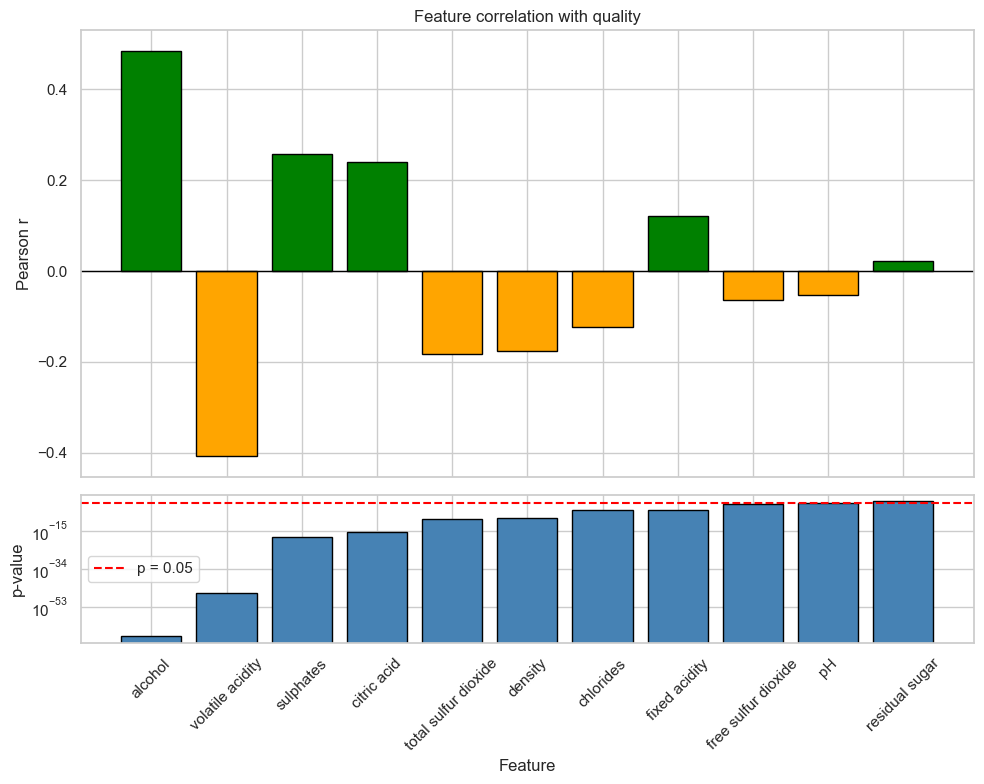

In [14]:
# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# Top: correlation values
colors = ["green" if v > 0 else "orange" for v in results["Correlation"]]
axes[0].bar(results["Feature"], results["Correlation"], color=colors, edgecolor="black")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("Pearson r")
axes[0].set_title("Feature correlation with quality")
axes[0].tick_params(axis="x", rotation=45)

# Bottom: p-values on log scale
axes[1].bar(results["Feature"], results["p-value"], color="steelblue", edgecolor="black")
axes[1].set_ylabel("p-value")
axes[1].set_yscale("log")
axes[1].axhline(0.05, color="red", linestyle="--", label="p = 0.05")
axes[1].legend()
axes[1].set_xlabel("Feature")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Observation / important caveat:** with n = 1143, almost every feature
comes back with p < 0.05 — including `residual sugar`, whose r is only
0.022. **Statistical significance here is NOT the same as practical
importance.** Large sample sizes make even trivially small correlations
"significant." For feature selection, rank by the **magnitude of r** (and
R², next), not by p-value pass/fail — p-value here only answers "is this
correlation distinguishable from exactly zero," not "is this correlation
useful."

# 6. R² — how much variance is actually explained

For a single-feature linear relationship, R² = r². It's the fraction of
variance in one variable "explained" by a straight-line relationship with
the other — a more intuitive, interpretable number than r itself for
judging whether a correlation is actually *substantial*.

In [15]:
results["R2"] = results["Correlation"] ** 2
results["pct_variance"] = round(results["R2"] * 100, 2)
results

,Feature,Correlation,p-value,R2,pct_variance
10,alcohol,0.484866,1.924653e-68,0.235095,23.51
1,volatile acidity,-0.407394,6.245963e-47,0.165969,16.60
9,sulphates,0.257710,8.506994e-19,0.066415,6.64
2,citric acid,0.240821,1.523989e-16,0.057995,5.80
6,total sulfur dioxide,-0.183339,4.248782e-10,0.033613,3.36
7,density,-0.175208,2.473727e-09,0.030698,3.07
4,chlorides,-0.124085,2.590555e-05,0.015397,1.54
0,fixed acidity,0.121970,3.556768e-05,0.014877,1.49
5,free sulfur dioxide,-0.063260,3.247603e-02,0.004002,0.40
8,pH,-0.052453,7.629053e-02,0.002751,0.28


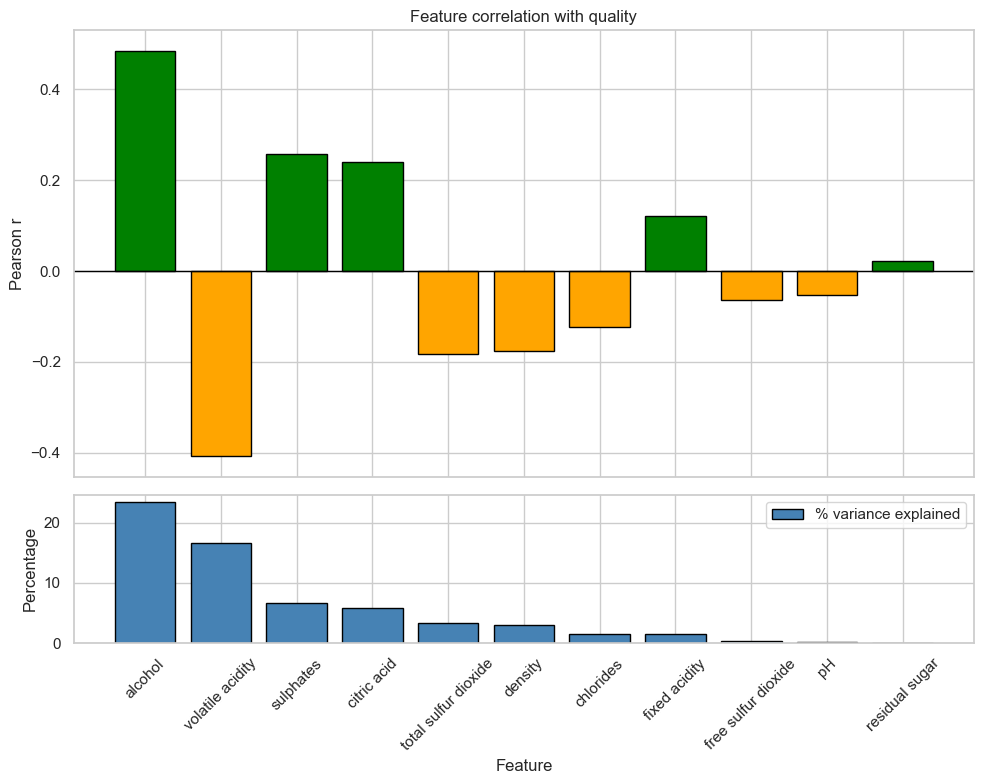

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

colors = ["green" if v > 0 else "orange" for v in results["Correlation"]]
axes[0].bar(results["Feature"], results["Correlation"], color=colors, edgecolor="black")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("Pearson r")
axes[0].set_title("Feature correlation with quality")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(results["Feature"], results["pct_variance"], color="steelblue", edgecolor="black", label="% variance explained")
axes[1].set_ylabel("Percentage")
axes[1].legend()
axes[1].set_xlabel("Feature")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Conclusion:** even the strongest single feature, `alcohol` (r ≈ 0.48),
only explains about 24% of the variance in `quality` on its own — R²
makes that concrete in a way p-value never does. This is the real argument
for *not* using p-value alone to keep/drop features: `residual sugar`
passes the significance test but explains a negligible fraction of a
percent of the variance. R² is doing the practical-importance job that the
p-value can't.

# 7. Redundancy — highly correlated feature PAIRS (not vs. target)

Now the second job: find features that duplicate each other. Threshold
chosen here: **|r| > 0.6** between two features (excluding the target).

In [17]:
# Define Threshold 
THRESHOLD = 0.6

feature = df.columns.drop("quality").tolist()
pairs = []

for i in range(len(feature)):
    for j in range(i+1, len(feature)):
        f1, f2 = feature[i], feature[j]
        r,p = pearsonr(df[f1],df[f2])
        pairs.append({"Feature_1":f1, "Feature_2":f2, "r":r, "p_value":p})

pairs_df = pd.DataFrame(pairs).sort_values(by="r",key=abs ,ascending=False)

# Extracting Highly Correlated Features Pairs

highly_corr_pairs = pairs_df[pairs_df["r"].abs() > THRESHOLD]
highly_corr_pairs

,Feature_1,Feature_2,r,p_value
7,fixed acidity,pH,-0.685163,3.121609e-159
6,fixed acidity,density,0.681501,6.648764e-157
1,fixed acidity,citric acid,0.673157,1.006159e-151
40,free sulfur dioxide,total sulfur dioxide,0.661093,1.578414e-144


**Observation:** `fixed acidity` shows up in most of the flagged pairs —
it's strongly related to `pH` (makes chemical sense: pH literally measures
acidity), `density`, and `citric acid`. `free sulfur dioxide` /
`total sulfur dioxide` is a separate, expected redundant pair (the "total"
is partly made up of the "free" form). These pairs are the ones worth
resolving before feeding this data into a linear model, where
multicollinearity inflates coefficient variance and makes them unstable.

# 8. Deciding which feature to reject — the basis for the decision

Rule used here: when two features are highly correlated with **each
other**, keep whichever one is more strongly correlated with the
**target**, drop the other. Applied greedily from the least
target-relevant feature upward, so a feature already rejected doesn't get
to "save" another feature by association.

In [18]:
target_relevance = corr_matrix["quality"].drop("quality").abs()
ranked_LTH = target_relevance.sort_values().index.tolist()

rejected = set()
rejection_reason = []

for feat in ranked_LTH:
    if feat in rejected:
        continue
    
    for other in ranked_LTH:
        if feat == other or other in rejected:
            continue
        if target_relevance[other] <= target_relevance[feat]:
            pass # only compare against something more relevant
        
        r_pair = corr_matrix.loc[feat, other]
        if abs(r_pair) > THRESHOLD:
            rejected.add(feat)
            rejection_reason.append({
                "rejected_feature": feat,
                "kept_feature": other,
                "r b/w them ": np.round(r_pair,3),
                "target_r_rejected":np.round(corr_matrix.loc[feat, "quality"],3),
                "target_r_kept":np.round(corr_matrix.loc[other, "quality"],3)
            })
            break

reason_df = pd.DataFrame(rejection_reason)
reason_df 

,rejected_feature,kept_feature,r b/w them,target_r_rejected,target_r_kept
0,pH,fixed acidity,-0.685,-0.052,0.122
1,free sulfur dioxide,total sulfur dioxide,0.661,-0.063,-0.183
2,fixed acidity,density,0.682,0.122,-0.175


In [19]:
kept_features = [f for f in feature if f not in rejected]
print(f"Rejected features ({len(rejected)}): {sorted(rejected)}")
print(f"Kept features ({len(kept_features)}) : {kept_features}")

Rejected features (3): ['fixed acidity', 'free sulfur dioxide', 'pH']
Kept features (8) : ['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']



**Conclusion:** each rejection has a concrete, traceable reason — a
specific feature it duplicates, and evidence that the *kept* feature is the
more useful one of the pair for predicting `quality`. That's the difference
between "I ran a correlation filter" and "I can explain every feature I
dropped," which is the point of building this as a reference.

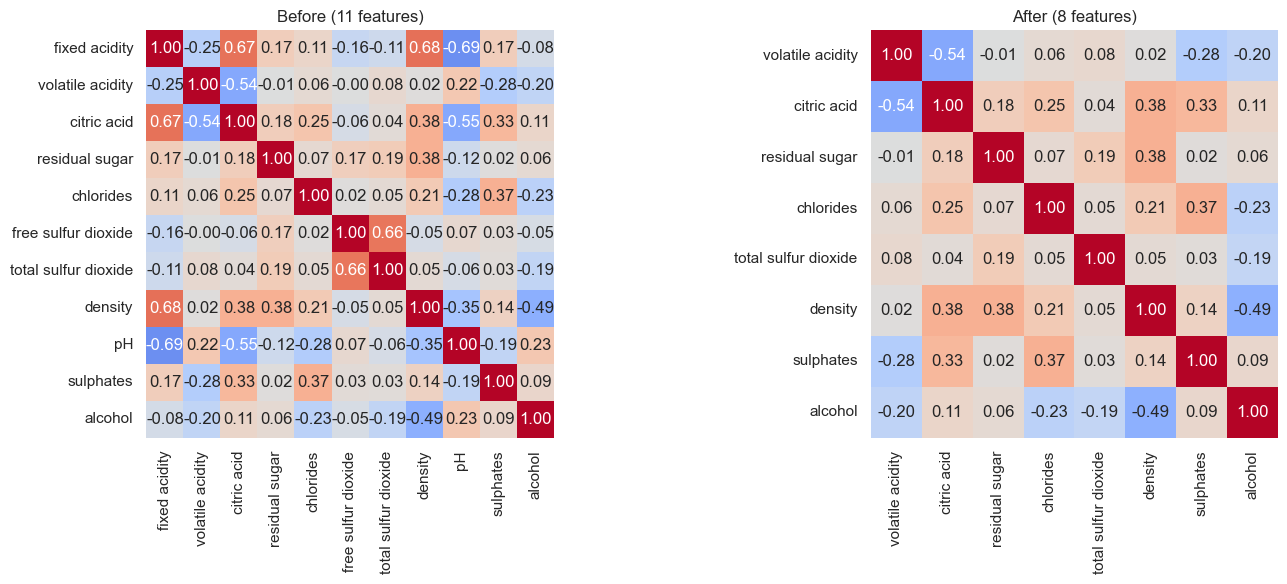

In [20]:
reduced_features = df[kept_features + ["quality"]]

fig, axes = plt.subplots(1,2, figsize=(15, 6))


# Before Feature Selection
sns.heatmap(df.drop(columns=["quality"]).corr(), annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, square=True, cbar=False, ax=axes[0])
axes[0].set_title(f"Before ({len(feature)} features)")

# After Feature Selection]
sns.heatmap(reduced_features.drop(columns=["quality"]).corr(), annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, cbar=False, ax=axes[1])
axes[1].set_title(f"After ({len(kept_features)} features)")
plt.tight_layout()
plt.show()


# 9. Model training and Evaluation

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error


In [22]:
def Train_Model(df):
    
    # Extracting the features and target variable
    X = df.drop(columns=["quality"])
    y = df["quality"]
    
    # Train/Test Split 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Define the model pipeline
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Evaluate the model
    y_pred = model.predict(X_test)
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred, zero_division=0)}")


### Before Feature Selection

In [23]:
Train_Model(df)

Accuracy: 0.6245
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.78      0.74        97
           6       0.59      0.63      0.61        92
           7       0.43      0.31      0.36        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.29      0.29      0.28       229
weighted avg       0.59      0.62      0.60       229



### After feature Selection

In [24]:
Train_Model(reduced_features)

Accuracy: 0.6332
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.78      0.74        97
           6       0.59      0.65      0.62        92
           7       0.45      0.31      0.37        29
           8       0.00      0.00      0.00         3

    accuracy                           0.63       229
   macro avg       0.29      0.29      0.29       229
weighted avg       0.59      0.63      0.61       229



# 10. Strategic Rules: When to Use vs. When to Avoid

### When to Use
*   **Continuous-to-Continuous Pipeline Blocks:** It is uniquely suited for regression tasks where both the explanatory features and the target variable are continuous numeric values.

*   **High-Dimensional Feature Condensation:** Highly effective for thinning out dense matrices where multiple sensors or economic indicators track nearly identical real-world phenomena.

*   **Linear Model Initialization:** Essential baseline preparation before training models that assume linear data structures.

### When to Avoid

*  **Linear relationships only.** Pearson r is blind to strong *non-linear* relationships — a feature could have r ≈ 0 with the target and still be
highly predictive through a curve or threshold effect. Spearman correlation (rank-based) or mutual information catch monotonic /non-linear relationships this method misses entirely.

*   **Categorical Data Structures:** Pearson’s correlation assumes a continuous, normal distribution. Do not use it on nominal categorical labels (e.g., "City Name") or binary variables, as the resulting metrics will be mathematically invalid.

*   **Non-Linear Relationships:** Pearson *only* detects straight-line relationships. If your feature and target share a perfect U-shaped quadratic or sinusoidal relationship, Pearson's \(r\) will be close to \(0\). Wiping out the feature based on this score will destroy a highly predictive, non-linear asset. 

    *(Correction: In non-linear cases, use **Spearman’s Rank Correlation** or **Mutual Information Scores** instead).*
*   **Outlier-Heavy Datasets:** The calculation relies heavily on variance from the mean. A single severe outlier can artificially inflate or completely deflate your correlation score.

* **p-value inflation with large n**, demonstrated directly in Step 5 —don't use p < 0.05 alone as a keep/drop rule once your sample size is in
  the hundreds or thousands; use r magnitude / R² instead.

* **Pairwise only** — this method resolves *pairwise* redundancy, not redundancy across 3+ features acting together (e.g. one feature being a
  near-linear combination of two others). VIF (Variance Inflation Factor) is the standard follow-up check for that if a linear model is downstream.



# 11 . Model Impact: Performance Analysis

### Models that Show Significant Performance Improvements

*   **Linear Regression & Generalized Linear Models (GLMs):** High multicollinearity destroys ordinary least squares (OLS) math by inflating the variance of coefficient estimates. This makes the model wildly sensitive to minor training changes. Dropping collinear features stabilizes coefficients and makes the model interpretable.

*   **Naïve Bayes:** This algorithm operates under the strict assumption that all input features are independent of each other given the class. Passing highly correlated features directly violates this axiom, causing the model to double-count overlapping signals and output overconfident, skewed probabilities.

*   **Regularized Models (Ridge / Lasso Regression):** While Lasso can technically drop features internally, removing highly correlated variables upfront simplifies the regularization penalty path, reducing optimization runtime and improving overall convergence speed.

### Models that Show Negligible to No Performance Improvements

*   **Tree-Based Ensembles (XGBoost, LightGBM, Random Forests):** Tree algorithms do not suffer from multicollinearity issues. If two features are highly correlated, a decision tree will simply pick whichever one yields a slightly better split at a given node. The presence of the other feature does not mathematically destabilize the tree or hurt final validation accuracy. Wiping them out will decrease training time and make features easier to interpret, but it won't notably boost model score metrics.

## Takeaway

Pearson correlation does two separate feature-selection jobs at once here: ranking features by linear relevance to the target (sanity-checked
with R²  NOT p-value alone), and pruning redundant feature PAIRS based on a traceable, target-aware rejection rule . The reduced set
(**8** features) keeps the target-relevant signal while removing the clearest multicollinearity.

**Next technique to try:** Spearman correlation as a quick check for monotonic non-linear relationships Pearson would miss, then VIF if a linear
model is the downstream target, or mutual information as the fully non-linear-aware version of the "relevance" half of this notebook.